# 🎯 Topic Modelling LDA dengan TF-IDF
## Dataset: Komentar YouTube Program Makan Bergizi (MBG)

**Objective:** Menganalisis topik-topik utama dari komentar YouTube tentang Program Makan Bergizi menggunakan Latent Dirichlet Allocation (LDA) dengan TF-IDF vectorization.

**Dataset:** BBC News Indonesia - "Setahun Program MBG - Siapa yang diuntungkan?"

**Total Comments:** 1,793 komentar

---

## 📦 BAGIAN 1: SETUP & IMPORT LIBRARIES

In [1]:
# Install required libraries (run once)
import subprocess
import sys

# List of required packages
required_packages = [
    'pandas',
    'numpy',
    'scikit-learn',
    'gensim',
    'nltk',
    'sastrawi',
    'matplotlib',
    'seaborn',
    'wordcloud',
    'pyLDAvis'
]

print("Installing required packages...")
for package in required_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    
print("✓ All packages installed successfully!")

Installing required packages...
✓ All packages installed successfully!


In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
import re
import logging
from datetime import datetime
import pickle
import os

# NLP Libraries
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer

# Gensim for LDA
from gensim import corpora, models
from gensim.models import CoherenceModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Suppress warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt', quiet=True)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [3]:
# Setup plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Create output directories
os.makedirs('output/data', exist_ok=True)
os.makedirs('output/models', exist_ok=True)
os.makedirs('output/visualizations', exist_ok=True)
os.makedirs('output/reports', exist_ok=True)

logger.info("Directories created successfully")
print("✓ Setup completed!")

2026-06-04 01:48:17,294 - INFO - Directories created successfully


✓ Setup completed!


---
## 📊 BAGIAN 2: EXPLORATORY DATA ANALYSIS (EDA)

In [4]:
# Load dataset
df = pd.read_excel('backup_data_gabungan_concat.xlsx')

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Komentar: {df.shape[0]:,}")
print(f"\nColumn Names & Types:")
print(df.dtypes)
print(f"\nFirst 5 Rows:")
display(df.head())

DATASET OVERVIEW

Dataset Shape: (6811, 6)
Total Komentar: 6,811

Column Names & Types:
Timestamp    object
Username     object
VideoID      object
Comment      object
Date         object
source       object
dtype: object

First 5 Rows:


,Timestamp,Username,VideoID,Comment,Date,source
0,2026-02-13T19:46:52Z,@DoroteusNiki,D9jL8fLw-SI,Gini dong jadi pejabat klu bohong jangan pakai...,2026-02-13T19:46:52Z,Merdeka
1,2026-01-13T08:42:21Z,@Jagokontruksi,D9jL8fLw-SI,Begitu ternyata cara mereka kerja meskipun fak...,2026-01-13T08:42:21Z,Merdeka
2,2026-01-05T02:50:32Z,@sopiangsyah1579,D9jL8fLw-SI,Pelayanan dan imformasi pihak BGN di daerah ti...,2026-01-05T02:50:32Z,Merdeka
3,2025-12-30T02:00:02Z,@RONNYALEXANDER-x2m,D9jL8fLw-SI,"Disaat MBG menyerap ayam, susu, ikan, daging, ...",2025-12-30T02:00:02Z,Merdeka
4,2025-12-29T22:02:10Z,@MasiahMasiah-j4z,D9jL8fLw-SI,"Laporkan juga menu roti 1000, buah potong 3 up...",2025-12-29T22:02:10Z,Merdeka


In [5]:
# Data Quality Check
print("\n" + "=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

print(f"\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print(f"\nData Types:")
print(df.dtypes)

# Memory usage
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


DATA QUALITY CHECK

Missing Values:
Timestamp    5870
VideoID      5870
dtype: int64

Duplicate Rows: 0

Data Types:
Timestamp    object
Username     object
VideoID      object
Comment      object
Date         object
source       object
dtype: object

Memory Usage: 3.36 MB


In [6]:
# Analyze Comment Column
print("\n" + "=" * 70)
print("COMMENT COLUMN ANALYSIS")
print("=" * 70)

# Remove any null values from Comment column
df_clean = df[df['Comment'].notna()].copy()
print(f"\nNon-null comments: {len(df_clean)} dari {len(df)}")

# Calculate comment statistics
df_clean['comment_length'] = df_clean['Comment'].str.len()
df_clean['word_count'] = df_clean['Comment'].str.split().str.len()

print(f"\n📊 Comment Length Statistics (characters):")
print(df_clean['comment_length'].describe())

print(f"\n📊 Word Count Statistics:")
print(df_clean['word_count'].describe())


COMMENT COLUMN ANALYSIS

Non-null comments: 6811 dari 6811

📊 Comment Length Statistics (characters):
count    6807.000000
mean      169.914500
std       221.714542
min         6.000000
25%        63.000000
50%       109.000000
75%       197.000000
max      5727.000000
Name: comment_length, dtype: float64

📊 Word Count Statistics:
count    6807.000000
mean       26.574556
std        33.492842
min         1.000000
25%        10.000000
50%        17.000000
75%        31.000000
max       791.000000
Name: word_count, dtype: float64


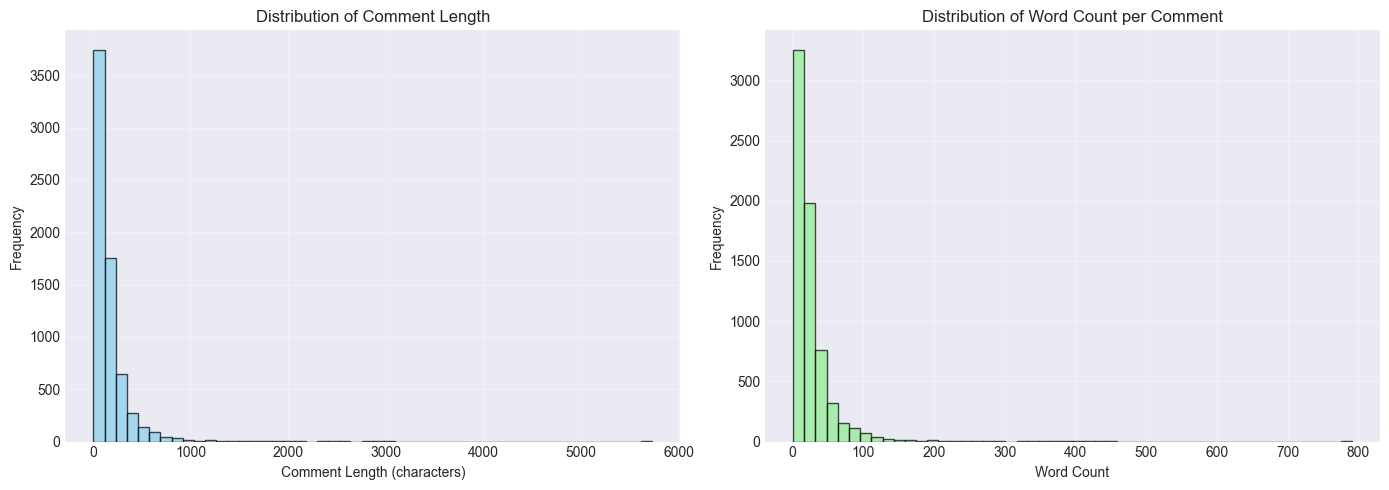

✓ Saved: 01_comment_statistics.png


In [7]:
# Visualize comment statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comment length distribution
axes[0].hist(df_clean['comment_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Comment Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Comment Length')
axes[0].grid(alpha=0.3)

# Word count distribution
axes[1].hist(df_clean['word_count'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Word Count per Comment')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/visualizations/01_comment_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 01_comment_statistics.png")

In [8]:
# Sample comments analysis
print("\n" + "=" * 70)
print("SAMPLE COMMENTS")
print("=" * 70)

print("\n🔹 Shortest Comments:")
for i, comment in enumerate(df_clean.nsmallest(3, 'comment_length')['Comment'].values, 1):
    print(f"{i}. {comment}")

print("\n🔹 Longest Comments:")
for i, comment in enumerate(df_clean.nlargest(3, 'comment_length')['Comment'].values, 1):
    print(f"{i}. {comment[:150]}...")

print("\n🔹 Random Comments:")
for i, comment in enumerate(df_clean.sample(3)['Comment'].values, 1):
    print(f"{i}. {comment}")


SAMPLE COMMENTS

🔹 Shortest Comments:
1. Bohong
2. Setuju
3. stop mbg

🔹 Longest Comments:
1. sejak kecil banyak dari kita sering diajukan pertanyaan sederhana apa citacitamu nak jawaban untuk pertanyaan ini biasanya datang begitu sajadokter gu...
2. program mbg harus dihentikan sementara karena dua alasan utama yaitu pertama letak permasalahan keracunan yang sebenarnya pada cara distribusi makanan...
3. pertanyaan yg masih gua bingung tuh gini, kita tau awal program ini dibuat dengan tujuan dan alasan untuk mencegah stunting, tapi ternyata untuk mence...

🔹 Random Comments:
1. masalah mbg tak bisa terpecahkan hanya akan menimbulkan masalah yang lebih parah
2. Setuju sama MBG,, tapi tolong disasar  ke yang benar2 membutuhkan dulu dan kasi paket makanan yang proper, gizinya beneran berkualitas.. kalau sudah rapih sistemnya bolehlah diexpand
3. makan bergizi gratis membawa berkah bagi siswa pedagang orang tua siswa


---
## 🧹 BAGIAN 3: TEXT PREPROCESSING

In [9]:
# =============================================================================
# LOAD NORMALIZATION DICTIONARY
# -----------------------------------------------------------------------------
# File: normalization_dict.csv (letakkan di folder yang sama dengan notebook)
# Kolom: 'slang' (kata tidak baku) dan 'baku' (kata baku)
# Tujuan: Menstandarkan kata-kata informal/slang dalam komentar YouTube
#         sebelum masuk ke tahap tokenisasi, stopword removal, dan stemming.
#
# Contoh:
#   'tdk'   -> 'tidak'
#   'yg'    -> 'yang'
#   'banget'-> 'sangat'
# =============================================================================

norm_df = pd.read_csv('normalization_dict_merged.csv')

# Validasi kolom
assert 'slang' in norm_df.columns and 'baku' in norm_df.columns, \
    "File normalization_dict.csv harus memiliki kolom 'slang' dan 'baku'!"

# Bersihkan: pastikan lowercase dan tidak ada spasi berlebih
norm_df['slang'] = norm_df['slang'].str.lower().str.strip()
norm_df['baku']  = norm_df['baku'].str.lower().str.strip()

# Hapus duplikat pada kolom slang (ambil yang pertama)
norm_df = norm_df.drop_duplicates(subset='slang', keep='first')

# Konversi ke dictionary Python: {slang: baku}
NORMALIZATION_DICT = dict(zip(norm_df['slang'], norm_df['baku']))

print(f"✓ Normalization dictionary loaded!")
print(f"  Total entri: {len(NORMALIZATION_DICT)}")
print(f"\n📝 Sample (10 entri pertama):")
for slang, baku in list(NORMALIZATION_DICT.items())[:10]:
    print(f"  '{slang}' -> '{baku}'")

✓ Normalization dictionary loaded!
  Total entri: 1629

📝 Sample (10 entri pertama):
  'abis' -> 'habis'
  'aja' -> 'saja'
  'ajah' -> 'saja'
  'aj' -> 'saja'
  'ajalah' -> 'saja'
  'ajla' -> 'saja'
  'ajaa' -> 'saja'
  'ajaah' -> 'saja'
  'ajaahhh' -> 'saja'
  'ajala' -> 'aja lah'


In [38]:
# Define Indonesian Stopwords
INDONESIAN_STOPWORDS = {
    'yang', 'untuk', 'pada', 'ke', 'para', 'namun', 'menurut', 'antara', 'dia', 'dua',
    'ia', 'seperti', 'jika', 'sehingga', 'kembali', 'dan', 'tidak', 'ini', 'karena',
    'kepada', 'oleh', 'saat', 'harus', 'sementara', 'setelah', 'belum', 'kami', 'sekitar',
    'bagi', 'serta', 'di', 'dari', 'telah', 'sebagai', 'masih', 'hal', 'ketika', 'adalah',
    'itu', 'dalam', 'bisa', 'bahwa', 'atau', 'hanya', 'kita', 'dengan', 'akan', 'juga',
    'ada', 'mereka', 'sudah', 'saya', 'terhadap', 'secara', 'agar', 'lain', 'anda',
    'begitu', 'mengapa', 'kenapa', 'yaitu', 'yakni', 'daripada', 'itulah', 'lagi', 'maka',
    'tentang', 'demi', 'dimana', 'kemana', 'pula', 'sambil', 'sebelum', 'sesudah', 'supaya',
    'guna', 'kah', 'pun', 'sampai', 'sedangkan', 'selagi', 'tetapi', 'apakah',
    'kecuali', 'sebab', 'selain', 'seolah', 'seraya', 'seterusnya', 'tanpa', 'agak', 'boleh',
    'dapat', 'dsb', 'dst', 'dll', 'dahulu', 'dulunya', 'anu', 'demikian', 'tapi', 'ingin',
    'nggak', 'mari', 'nanti', 'melainkan', 'oh', 'ok', 'seharusnya', 'sebetulnya',
    'setiap', 'setidaknya', 'sesuatu', 'pasti', 'saja', 'toh', 'ya', 'walau', 'tolong',
    'tentu', 'amat', 'apalagi', 'bagaimanapun', 'pak', 'bapak', 'nya', 'yg', 'sama', 'apa',
    'aja', 'mana','jadi', 'nih', 'loh', 'kok', 'deh', 'lah', 'siapa', 'kalian', 'kami', 'kamu', 'saya',
    'dia', 'mereka', 'kita', 'anda', 'saya', 'kamu', 'kalian', 'kami', 'mereka', 'dia', 'kalian', 'kami', 'kamu', 'saya', 'dia', 'mereka',
    'tutup', 'mulai', 'selesai', 'awal', 'akhir', 'sekarang', 'kemarin', 'besok','kalau',
    'beri', 'tdk', 'kok', 'loh', 'nih', 'deh', 'lah', 'siapa', 'kalian', 'kami', 'kamu', 'saya','mbg'
}

print(f"Total Stopwords Defined: {len(INDONESIAN_STOPWORDS)}")
print(f"Sample Stopwords: {list(INDONESIAN_STOPWORDS)[:20]}")

Total Stopwords Defined: 152
Sample Stopwords: ['adalah', 'terhadap', 'sebagai', 'siapa', 'demi', 'apa', 'kecuali', 'besok', 'itulah', 'kalau', 'tentang', 'sampai', 'mengapa', 'sambil', 'tidak', 'seraya', 'saat', 'sehingga', 'kah', 'selain']


In [39]:
# Initialize Sastrawi Stemmer
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

print("✓ Sastrawi Stemmer initialized")

# Test stemmer
test_words = ['makan', 'mempakan', 'memakan', 'program', 'diprogram', 'berprogram']
print("\n📝 Stemming Examples:")
for word in test_words:
    stemmed = stemmer.stem(word)
    print(f"  {word:15} -> {stemmed}")

✓ Sastrawi Stemmer initialized

📝 Stemming Examples:
  makan           -> makan
  mempakan        -> pakan
  memakan         -> makan
  program         -> program
  diprogram       -> program
  berprogram      -> program


In [40]:
# Create comprehensive preprocessing function
class TextPreprocessor:
    """
    Complete text preprocessing pipeline for Indonesian text.

    Pipeline (urutan eksekusi):
    1. clean_text()       - Hapus URL, mention, email, karakter spesial, lowercase
    2. normalize_text()   - Ganti kata slang/informal -> kata baku (dari normalization_dict.csv)
    3. tokenize()         - Pisah teks menjadi token/kata
    4. remove_stopwords() - Buang stopwords Bahasa Indonesia
    5. stem()             - Stemming menggunakan Sastrawi

    Mengapa normalisasi SETELAH clean_text dan SEBELUM tokenize?
    - clean_text() memastikan teks sudah lowercase dan bebas noise
      sehingga pencocokan kamus normalisasi lebih akurat.
    - Normalisasi bekerja di level string (bukan token), sehingga harus
      dilakukan sebelum teks dipecah menjadi token.
    - Stemmer (Sastrawi) dirancang untuk kata baku, bukan kata slang.
      Normalisasi lebih dulu memastikan stemmer bekerja optimal.
    """

    def __init__(self, stemmer, stopwords, norm_dict):
        self.stemmer   = stemmer
        self.stopwords = stopwords
        self.norm_dict = norm_dict   # dict {slang: baku} dari normalization_dict.csv
        self.stats = {
            'original': 0,
            'after_cleaning': 0,
            'after_normalization': 0,
            'after_removal': 0,
            'final': 0
        }

    def clean_text(self, text):
        """
        Step 1 - Bersihkan teks:
        - Hapus URL, mention (@user), email
        - Hapus karakter spesial (hanya huruf, angka, spasi)
        - Normalisasi whitespace
        - Lowercase
        """
        if not isinstance(text, str):
            return ''

        text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Hapus URL
        text = re.sub(r'@\w+', '', text)                      # Hapus mention
        text = re.sub(r'\S+@\S+', '', text)                   # Hapus email
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)          # Hapus karakter spesial
        text = ' '.join(text.split())                          # Normalisasi whitespace
        text = text.lower()                                    # Lowercase

        return text.strip()

    def normalize_text(self, text):
        """
        Step 2 - Normalisasi kata slang/informal ke kata baku.

        Menggunakan kamus dari normalization_dict.csv.
        Pencocokan dilakukan per-kata (word boundary) agar tidak
        mengganti bagian dari kata yang lebih panjang.

        Contoh:
          'gk ngerti'   -> 'tidak mengerti'
          'bgt banget'  -> 'sangat sangat'
          'udh makan'   -> 'sudah makan'
        """
        if not text:
            return text

        # Tokenisasi sementara per kata, lalu ganti jika ada di kamus
        words = text.split()
        normalized = [self.norm_dict.get(word, word) for word in words]
        return ' '.join(normalized)

    def tokenize(self, text):
        """
        Step 3 - Tokenisasi teks menjadi list kata
        """
        return word_tokenize(text)

    def remove_stopwords(self, tokens):
        """
        Step 4 - Hapus stopwords Bahasa Indonesia
        """
        return [t for t in tokens if t.lower() not in self.stopwords]

    def stem(self, tokens):
        """
        Step 5 - Stemming menggunakan Sastrawi
        Sastrawi bekerja optimal pada kata baku,
        itulah alasan normalisasi dilakukan lebih awal.
        """
        return [self.stemmer.stem(token) for token in tokens]

    def preprocess(self, text):
        """
        Jalankan full preprocessing pipeline:
        clean -> normalize -> tokenize -> stopword -> stem
        """
        self.stats['original'] += 1

        # Step 1: Clean
        text = self.clean_text(text)
        if text:
            self.stats['after_cleaning'] += 1

        # Step 2: Normalize (slang -> baku)
        text = self.normalize_text(text)
        if text:
            self.stats['after_normalization'] += 1

        # Step 3: Tokenize
        tokens = self.tokenize(text)

        # Step 4: Remove stopwords
        tokens = self.remove_stopwords(tokens)
        if tokens:
            self.stats['after_removal'] += 1

        # Step 5: Stem
        tokens = self.stem(tokens)

        result = ' '.join(tokens)
        if result.strip():
            self.stats['final'] += 1

        return result

    def preprocess_batch(self, texts):
        """
        Preprocess banyak teks sekaligus, dengan progress logging.
        """
        logger.info(f"Starting preprocessing of {len(texts)} documents...")
        processed = []

        for i, text in enumerate(texts):
            if (i + 1) % 500 == 0:
                logger.info(f"  Processed {i+1}/{len(texts)} documents")
            processed.append(self.preprocess(text))

        logger.info("Preprocessing completed!")
        return processed

print('✓ TextPreprocessor class created (dengan normalize_text step)')

✓ TextPreprocessor class created (dengan normalize_text step)


In [41]:
# Initialize preprocessor and run preprocessing
# NORMALIZATION_DICT diteruskan sebagai argumen ketiga
preprocessor = TextPreprocessor(stemmer, INDONESIAN_STOPWORDS, NORMALIZATION_DICT)

print('\n' + '=' * 70)
print('RUNNING TEXT PREPROCESSING')
print('=' * 70)
print('\nPipeline: clean -> normalize -> tokenize -> stopword -> stem')

# Get comments
comments = df_clean['Comment'].values

# Preprocess all comments
processed_comments = preprocessor.preprocess_batch(comments)

# Store in dataframe
df_clean['processed_comment'] = processed_comments

# Print statistics
print('\n📊 PREPROCESSING STATISTICS:')
print(f"  Original documents      : {preprocessor.stats['original']}")
print(f"  After cleaning          : {preprocessor.stats['after_cleaning']}")
print(f"  After normalization     : {preprocessor.stats['after_normalization']}")
print(f"  After stopword removal  : {preprocessor.stats['after_removal']}")
print(f"  Final documents         : {preprocessor.stats['final']}")

# Remove empty documents
df_processed = df_clean[df_clean['processed_comment'].str.len() > 0].copy()
print(f"\n  Documents after removing empty: {len(df_processed)}")
print(f"  Documents removed             : {len(df_clean) - len(df_processed)}")

2026-06-04 02:53:36,103 - INFO - Starting preprocessing of 6811 documents...



RUNNING TEXT PREPROCESSING

Pipeline: clean -> normalize -> tokenize -> stopword -> stem


2026-06-04 02:58:35,708 - INFO -   Processed 500/6811 documents
2026-06-04 03:01:37,606 - INFO -   Processed 1000/6811 documents
2026-06-04 03:04:01,286 - INFO -   Processed 1500/6811 documents
2026-06-04 03:07:10,602 - INFO -   Processed 2000/6811 documents
2026-06-04 03:10:03,520 - INFO -   Processed 2500/6811 documents
2026-06-04 03:12:45,346 - INFO -   Processed 3000/6811 documents
2026-06-04 03:15:37,729 - INFO -   Processed 3500/6811 documents
2026-06-04 03:18:17,247 - INFO -   Processed 4000/6811 documents
2026-06-04 03:20:55,718 - INFO -   Processed 4500/6811 documents
2026-06-04 03:23:40,366 - INFO -   Processed 5000/6811 documents
2026-06-04 03:26:24,927 - INFO -   Processed 5500/6811 documents
2026-06-04 03:29:28,280 - INFO -   Processed 6000/6811 documents
2026-06-04 03:32:03,155 - INFO -   Processed 6500/6811 documents
2026-06-04 03:33:11,444 - INFO - Preprocessing completed!



📊 PREPROCESSING STATISTICS:
  Original documents      : 6811
  After cleaning          : 6807
  After normalization     : 6807
  After stopword removal  : 6805
  Final documents         : 6805

  Documents after removing empty: 6805
  Documents removed             : 6


In [42]:
# Display preprocessing examples (before vs after)
print('\n' + '=' * 70)
print('PREPROCESSING EXAMPLES (BEFORE vs AFTER)')
print('=' * 70)

sample_indices = np.random.choice(len(df_processed), 5, replace=False)

for idx in sample_indices:
    original  = df_processed.iloc[idx]['Comment']
    processed = df_processed.iloc[idx]['processed_comment']

    # Tampilkan juga hasil intermediate normalisasi untuk verifikasi
    cleaned    = preprocessor.clean_text(original)
    normalized = preprocessor.normalize_text(cleaned)

    print(f"\n📝 Example {idx + 1}:")
    print(f"  ORIGINAL   : {original[:80]}")
    print(f"  CLEANED    : {cleaned[:80]}")
    print(f"  NORMALIZED : {normalized[:80]}")
    print(f"  FINAL      : {processed[:80]}")


PREPROCESSING EXAMPLES (BEFORE vs AFTER)

📝 Example 2724:
  ORIGINAL   : udahlah mbg stop ganti dengan susu 1lttelor buah2an per 3 hari dr sekolh lgsg ad
  CLEANED    : udahlah mbg stop ganti dengan susu 1lttelor buah2an per 3 hari dr sekolh lgsg ad
  NORMALIZED : udahlah mbg stop ganti dengan susu 1lttelor buah2an per 3 hari dari sekolah lgsg
  FINAL      : udahlah stop ganti susu 1lttelor buah2an per 3 hari sekolah lgsg lapang kerja ng

📝 Example 877:
  ORIGINAL   : yang untung buesaarr ya cuman pemilik yayasan yang berafiliasi sama rezim yang l
  CLEANED    : yang untung buesaarr ya cuman pemilik yayasan yang berafiliasi sama rezim yang l
  NORMALIZED : yang untung buesaarr ya hanya pemilik yayasan yang berafiliasi sama rezim yang l
  FINAL      : untung buesaarr milik yayasan afiliasi rezim laen mah cerita

📝 Example 1458:
  ORIGINAL   : yang diuntungkan orang kaya yang punya dapur mbg
  CLEANED    : yang diuntungkan orang kaya yang punya dapur mbg
  NORMALIZED : yang diuntungkan 

In [43]:
# Save preprocessed data
df_processed.to_csv('output/data/preprocessed_comments.csv', index=False)
print("✓ Preprocessed data saved: output/data/preprocessed_comments.csv")

# Statistics
print(f"\nProcessed dataset shape: {df_processed.shape}")
print(f"Processed documents: {len(df_processed)}")

✓ Preprocessed data saved: output/data/preprocessed_comments.csv

Processed dataset shape: (6805, 9)
Processed documents: 6805


---
## 📊 BAGIAN 4: TF-IDF VECTORIZATION

In [44]:
print("\n" + "=" * 70)
print("TF-IDF VECTORIZATION")
print("=" * 70)

# Initialize TfidfVectorizer with optimized parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # Max number of features
    min_df=2,               # Min document frequency
    max_df=0.8,             # Max document frequency
    ngram_range=(1, 2),     # Unigram and bigram
    norm='l2',              # L2 normalization
    sublinear_tf=True       # Apply sublinear tf scaling
)

print("\n📋 TF-IDF Parameters:")
print(f"  max_features: 5000")
print(f"  min_df: 2")
print(f"  max_df: 0.8")
print(f"  ngram_range: (1, 2)")
print(f"  Normalization: L2")

# Fit and transform
print("\n🔄 Fitting TF-IDF vectorizer...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df_processed['processed_comment'].values)

print(f"\n✓ TF-IDF vectorization completed!")
print(f"\n📊 TF-IDF Matrix Information:")
print(f"  Shape: {tfidf_matrix.shape}")
print(f"  Documents: {tfidf_matrix.shape[0]}")
print(f"  Features: {tfidf_matrix.shape[1]}")
print(f"  Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")
print(f"  Non-zero entries: {tfidf_matrix.nnz:,}")


TF-IDF VECTORIZATION

📋 TF-IDF Parameters:
  max_features: 5000
  min_df: 2
  max_df: 0.8
  ngram_range: (1, 2)
  Normalization: L2

🔄 Fitting TF-IDF vectorizer...

✓ TF-IDF vectorization completed!

📊 TF-IDF Matrix Information:
  Shape: (6805, 5000)
  Documents: 6805
  Features: 5000
  Sparsity: 99.67%
  Non-zero entries: 113,590


In [45]:
# Get feature names
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# Get IDF scores
idf_scores = tfidf_vectorizer.idf_

# Find top features by IDF
top_indices = np.argsort(idf_scores)[-30:][::-1]
top_features = feature_names[top_indices]
top_scores = idf_scores[top_indices]

print("\n📊 Top 30 Features by IDF Score:")
for i, (feature, score) in enumerate(zip(top_features, top_scores), 1):
    print(f"  {i:2d}. {feature:20s} -> {score:.4f}")


📊 Top 30 Features by IDF Score:
   1. komunitas            -> 8.7269
   2. kembang biak         -> 8.7269
   3. kamar                -> 8.7269
   4. kos                  -> 8.7269
   5. krisna               -> 8.7269
   6. rempah               -> 8.7269
   7. korupsi koruptor     -> 8.7269
   8. lemak                -> 8.7269
   9. mnjdi                -> 8.7269
  10. orang kantin         -> 8.7269
  11. bps                  -> 8.7269
  12. biskuit              -> 8.7269
  13. bla                  -> 8.7269
  14. perlu bayar          -> 8.7269
  15. 190                  -> 8.7269
  16. daulat gizi          -> 8.7269
  17. daftar menu          -> 8.7269
  18. cawe                 -> 8.7269
  19. makan tinggi         -> 8.7269
  20. ne                   -> 8.7269
  21. anakibu hamil        -> 8.7269
  22. anakibu              -> 8.7269
  23. gesa                 -> 8.7269
  24. gram                 -> 8.7269
  25. gizi anakibu         -> 8.7269
  26. undang undang        -> 8.7269
  27.

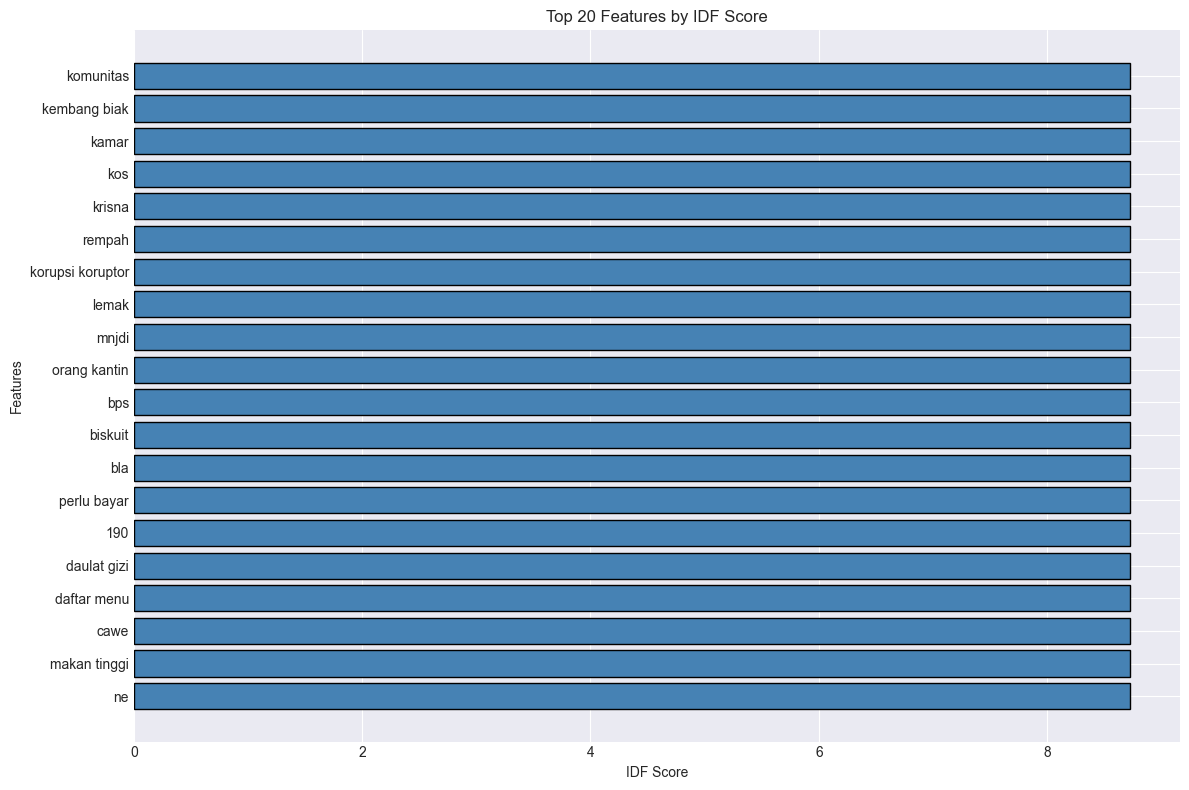

✓ Saved: 02_top_idf_features.png


In [46]:
# Visualize top features
plt.figure(figsize=(12, 8))
plt.barh(top_features[:20][::-1], top_scores[:20][::-1], color='steelblue', edgecolor='black')
plt.xlabel('IDF Score')
plt.ylabel('Features')
plt.title('Top 20 Features by IDF Score')
plt.tight_layout()
plt.savefig('output/visualizations/02_top_idf_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 02_top_idf_features.png")

---
## 🔬 BAGIAN 5: PREPARE DATA FOR GENSIM LDA

In [47]:
print("\n" + "=" * 70)
print("PREPARING GENSIM CORPUS & DICTIONARY")
print("=" * 70)

# Convert to gensim format
# Create list of tokenized documents
texts = [doc.split() for doc in df_processed['processed_comment'].values]

print(f"\nTotal documents for LDA: {len(texts)}")

# Create dictionary
print("\n🔄 Creating Gensim Dictionary...")
dictionary = corpora.Dictionary(texts)

print(f"✓ Dictionary created!")
print(f"  Total unique terms: {len(dictionary)}")

# Filter extreme words
print("\n🔄 Filtering extreme terms...")
dictionary.filter_extremes(
    no_below=2,      # Min documents
    no_above=0.8,    # Max documents
    keep_n=100000    # Keep max n terms
)

print(f"✓ After filtering:")
print(f"  Total unique terms: {len(dictionary)}")

# Create corpus (bag of words)
print("\n🔄 Creating Corpus...")
corpus = [dictionary.doc2bow(text) for text in texts]

print(f"✓ Corpus created!")
print(f"  Total documents: {len(corpus)}")
print(f"  Avg words per document: {np.mean([len(doc) for doc in corpus]):.1f}")

2026-06-04 03:33:13,816 - INFO - adding document #0 to Dictionary<0 unique tokens: []>



PREPARING GENSIM CORPUS & DICTIONARY

Total documents for LDA: 6805

🔄 Creating Gensim Dictionary...


2026-06-04 03:33:14,088 - INFO - built Dictionary<13326 unique tokens: ['15', '6', '7', 'ahok', 'bagus']...> from 6805 documents (total 120909 corpus positions)
2026-06-04 03:33:14,090 - INFO - Dictionary lifecycle event {'msg': "built Dictionary<13326 unique tokens: ['15', '6', '7', 'ahok', 'bagus']...> from 6805 documents (total 120909 corpus positions)", 'datetime': '2026-06-04T03:33:14.090331', 'gensim': '4.4.0', 'python': '3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-06-04 03:33:14,117 - INFO - discarding 8885 tokens: [('tafsir', 1), ('byr2', 1), ('imformasi', 1), ('cubit', 1), ('uprit', 1), ('wah2', 1), ('wihhh', 1), ('laporanya', 1), ('bohongggg', 1), ('modusssss', 1)]...
2026-06-04 03:33:14,119 - INFO - keeping 4441 tokens which were in no less than 2 and no more than 5444 (=80.0%) documents
2026-06-04 03:33:14,134 - INFO - resulting dictionary: Dictionary<4441 unique tokens:

✓ Dictionary created!
  Total unique terms: 13326

🔄 Filtering extreme terms...
✓ After filtering:
  Total unique terms: 4441

🔄 Creating Corpus...
✓ Corpus created!
  Total documents: 6805
  Avg words per document: 13.9


---
## 🎯 BAGIAN 6: FIND OPTIMAL NUMBER OF TOPICS

In [48]:
print("\n" + "=" * 70)
print("FINDING OPTIMAL NUMBER OF TOPICS")
print("=" * 70)

# Test different numbers of topics
topics_range = range(2, 11)  # Test 2-10 topics (adjusted from your 2-5 request)
coherence_scores = {}
perplexity_scores = {}
models_dict = {}

print(f"\nTesting topics from {min(topics_range)} to {max(topics_range)}...\n")

for num_topics in topics_range:
    print(f"🔄 Training LDA with {num_topics} topics...", end=" ")
    
    # Train model
    lda_model = models.LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,              # Number of passes through corpus
        workers=4,              # Number of worker processes
        minimum_probability=0.0,
        per_word_topics=True
    )
    
    # Calculate coherence score
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model.get_coherence()
    
    # Calculate perplexity
    perplexity = lda_model.log_perplexity(corpus)
    
    # Store results
    coherence_scores[num_topics] = coherence_score
    perplexity_scores[num_topics] = perplexity
    models_dict[num_topics] = lda_model
    
    print(f"✓ Coherence: {coherence_score:.4f}, Perplexity: {perplexity:.4f}")

print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)

2026-06-04 03:33:14,497 - INFO - using symmetric alpha at 0.5
2026-06-04 03:33:14,499 - INFO - using symmetric eta at 0.5
2026-06-04 03:33:14,503 - INFO - using serial LDA version on this node
2026-06-04 03:33:14,506 - INFO - running online LDA training, 2 topics, 10 passes over the supplied corpus of 6805 documents, updating every 8000 documents, evaluating every ~6805 documents, iterating 50x with a convergence threshold of 0.001000
2026-06-04 03:33:14,510 - INFO - training LDA model using 4 processes



FINDING OPTIMAL NUMBER OF TOPICS

Testing topics from 2 to 10...

🔄 Training LDA with 2 topics... 

2026-06-04 03:33:25,663 - INFO - PROGRESS: pass 0, dispatched chunk #0 = documents up to #2000/6805, outstanding queue size 1
2026-06-04 03:33:25,676 - INFO - PROGRESS: pass 0, dispatched chunk #1 = documents up to #4000/6805, outstanding queue size 2
2026-06-04 03:33:25,689 - INFO - PROGRESS: pass 0, dispatched chunk #2 = documents up to #6000/6805, outstanding queue size 3
2026-06-04 03:33:25,701 - INFO - PROGRESS: pass 0, dispatched chunk #3 = documents up to #6805/6805, outstanding queue size 4
2026-06-04 03:33:28,294 - INFO - topic #0 (0.500): 0.031*"makan" + 0.017*"anak" + 0.017*"program" + 0.016*"sekolah" + 0.012*"banyak" + 0.011*"gizi" + 0.011*"gratis" + 0.009*"uang" + 0.008*"perintah" + 0.008*"baik"
2026-06-04 03:33:28,297 - INFO - topic #1 (0.500): 0.027*"makan" + 0.022*"program" + 0.014*"sekolah" + 0.013*"gratis" + 0.012*"anak" + 0.011*"lebih" + 0.011*"baik" + 0.011*"orang" + 0.009*"gizi" + 0.008*"banyak"
2026-06-04 03:33:28,299 - INFO - topic diff=1.475208, rho=1.000000
202

✓ Coherence: 0.5146, Perplexity: -6.9309
🔄 Training LDA with 3 topics... 

2026-06-04 03:34:37,036 - INFO - PROGRESS: pass 0, dispatched chunk #0 = documents up to #2000/6805, outstanding queue size 1
2026-06-04 03:34:37,050 - INFO - PROGRESS: pass 0, dispatched chunk #1 = documents up to #4000/6805, outstanding queue size 2
2026-06-04 03:34:37,065 - INFO - PROGRESS: pass 0, dispatched chunk #2 = documents up to #6000/6805, outstanding queue size 3
2026-06-04 03:34:37,082 - INFO - PROGRESS: pass 0, dispatched chunk #3 = documents up to #6805/6805, outstanding queue size 4
2026-06-04 03:34:39,499 - INFO - topic #0 (0.333): 0.025*"makan" + 0.015*"sekolah" + 0.013*"banyak" + 0.013*"program" + 0.011*"gizi" + 0.010*"untung" + 0.010*"gratis" + 0.010*"anak" + 0.009*"uang" + 0.008*"baik"
2026-06-04 03:34:39,500 - INFO - topic #1 (0.333): 0.021*"makan" + 0.019*"program" + 0.013*"gratis" + 0.013*"sekolah" + 0.012*"baik" + 0.012*"lebih" + 0.011*"orang" + 0.009*"buat" + 0.008*"banyak" + 0.008*"gizi"
2026-06-04 03:34:39,502 - INFO - topic #2 (0.333): 0.038*"makan" + 0.024

...

✓ Coherence: 0.4827, Perplexity: -7.0923
🔄 Training LDA with 9 topics... 

2026-06-04 03:41:09,023 - INFO - PROGRESS: pass 0, dispatched chunk #0 = documents up to #2000/6805, outstanding queue size 1
2026-06-04 03:41:09,035 - INFO - PROGRESS: pass 0, dispatched chunk #1 = documents up to #4000/6805, outstanding queue size 2
2026-06-04 03:41:09,047 - INFO - PROGRESS: pass 0, dispatched chunk #2 = documents up to #6000/6805, outstanding queue size 3
2026-06-04 03:41:09,058 - INFO - PROGRESS: pass 0, dispatched chunk #3 = documents up to #6805/6805, outstanding queue size 4
2026-06-04 03:41:10,798 - INFO - topic #2 (0.111): 0.046*"makan" + 0.025*"anak" + 0.024*"program" + 0.014*"gratis" + 0.014*"sekolah" + 0.012*"perintah" + 0.011*"banyak" + 0.009*"rakyat" + 0.009*"gizi" + 0.009*"lebih"
2026-06-04 03:41:10,800 - INFO - topic #4 (0.111): 0.020*"baik" + 0.013*"makan" + 0.011*"perintah" + 0.010*"banyak" + 0.010*"lebih" + 0.008*"program" + 0.008*"henti" + 0.008*"kan" + 0.007*"gizi" + 0.006*"semua"
2026-06-04 03:41:10,803 - INFO - topic #5 (0.111): 0.028*"makan" + 0

✓ Coherence: 0.4712, Perplexity: -7.1064
🔄 Training LDA with 10 topics... 

2026-06-04 03:42:12,369 - INFO - PROGRESS: pass 0, dispatched chunk #0 = documents up to #2000/6805, outstanding queue size 1
2026-06-04 03:42:12,382 - INFO - PROGRESS: pass 0, dispatched chunk #1 = documents up to #4000/6805, outstanding queue size 2
2026-06-04 03:42:12,395 - INFO - PROGRESS: pass 0, dispatched chunk #2 = documents up to #6000/6805, outstanding queue size 3
2026-06-04 03:42:12,409 - INFO - PROGRESS: pass 0, dispatched chunk #3 = documents up to #6805/6805, outstanding queue size 4
2026-06-04 03:42:14,622 - INFO - topic #0 (0.100): 0.029*"makan" + 0.018*"banyak" + 0.014*"untung" + 0.012*"program" + 0.012*"sekolah" + 0.012*"gratis" + 0.011*"uang" + 0.009*"gizi" + 0.008*"perintah" + 0.008*"kerja"
2026-06-04 03:42:14,624 - INFO - topic #4 (0.100): 0.023*"baik" + 0.017*"makan" + 0.011*"perintah" + 0.011*"banyak" + 0.010*"semua" + 0.010*"lebih" + 0.009*"kan" + 0.008*"program" + 0.007*"gizi" + 0.007*"prabowo"
2026-06-04 03:42:14,626 - INFO - topic #3 (0.100): 0.031*"program"

✓ Coherence: 0.4783, Perplexity: -7.1315

EVALUATION RESULTS


In [49]:
# Display evaluation results
print("\n📊 Coherence & Perplexity Scores:")
print(f"\n{'Topics':<10} {'Coherence':<15} {'Perplexity':<15}")
print("-" * 40)
for topics in topics_range:
    print(f"{topics:<10} {coherence_scores[topics]:<15.4f} {perplexity_scores[topics]:<15.4f}")

# Find optimal
optimal_topics = max(coherence_scores, key=coherence_scores.get)
max_coherence = coherence_scores[optimal_topics]

print(f"\n🎯 Optimal number of topics: {optimal_topics}")
print(f"   Coherence Score: {max_coherence:.4f}")


📊 Coherence & Perplexity Scores:

Topics     Coherence       Perplexity     
----------------------------------------
2          0.5146          -6.9309        
3          0.5218          -6.9464        
4          0.5247          -6.9889        
5          0.5044          -7.0240        
6          0.4861          -7.0476        
7          0.4962          -7.0674        
8          0.4827          -7.0923        
9          0.4712          -7.1064        
10         0.4783          -7.1315        

🎯 Optimal number of topics: 4
   Coherence Score: 0.5247


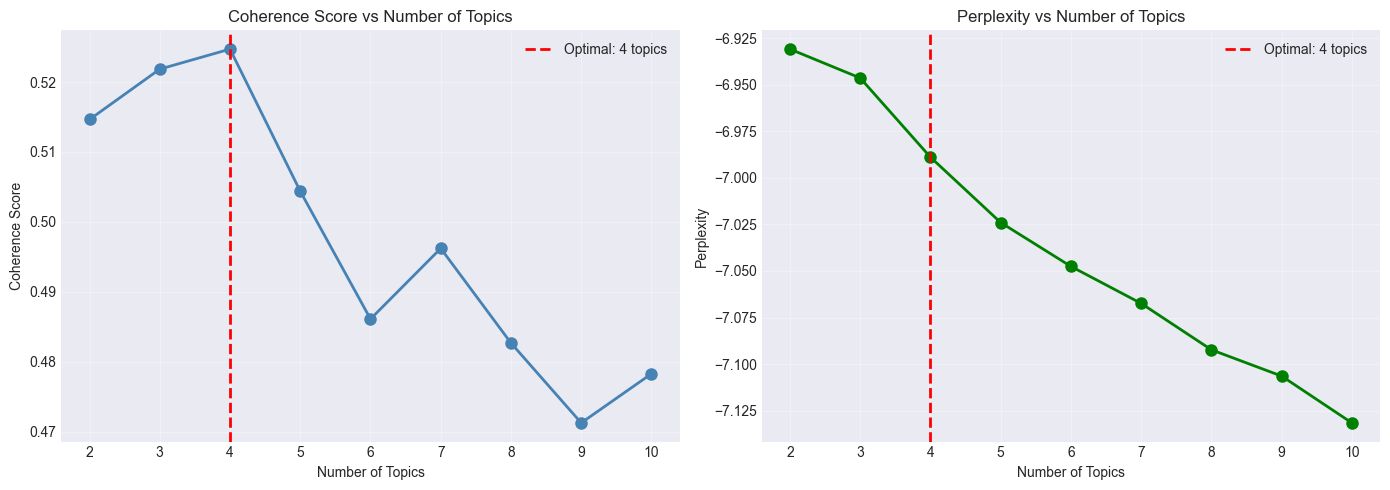

✓ Saved: 03_coherence_perplexity.png


In [50]:
# Visualize coherence and perplexity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coherence score
topics_list = list(coherence_scores.keys())
coherence_list = list(coherence_scores.values())

axes[0].plot(topics_list, coherence_list, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].axvline(x=optimal_topics, color='red', linestyle='--', linewidth=2, label=f'Optimal: {optimal_topics} topics')
axes[0].set_xlabel('Number of Topics')
axes[0].set_ylabel('Coherence Score')
axes[0].set_title('Coherence Score vs Number of Topics')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(topics_list)

# Perplexity score
perplexity_list = list(perplexity_scores.values())

axes[1].plot(topics_list, perplexity_list, 'o-', linewidth=2, markersize=8, color='green')
axes[1].axvline(x=optimal_topics, color='red', linestyle='--', linewidth=2, label=f'Optimal: {optimal_topics} topics')
axes[1].set_xlabel('Number of Topics')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Perplexity vs Number of Topics')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(topics_list)

plt.tight_layout()
plt.savefig('output/visualizations/03_coherence_perplexity.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 03_coherence_perplexity.png")

---
## 🚀 BAGIAN 7: TRAIN FINAL LDA MODEL

In [51]:
print("\n" + "=" * 70)
print("TRAINING FINAL LDA MODEL")
print("=" * 70)

# Select optimal model or use best coherence
final_lda_model = models_dict[optimal_topics]

print(f"\n✓ Final LDA Model selected with {optimal_topics} topics")
print(f"  Coherence Score: {coherence_scores[optimal_topics]:.4f}")

# Save the model
final_lda_model.save('output/models/lda_model_final.model')
print(f"\n✓ Model saved: output/models/lda_model_final.model")

2026-06-04 03:43:08,348 - INFO - LdaState lifecycle event {'fname_or_handle': 'output/models/lda_model_final.model.state', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-06-04T03:43:08.348678', 'gensim': '4.4.0', 'python': '3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'saving'}
2026-06-04 03:43:08,355 - INFO - saved output/models/lda_model_final.model.state
2026-06-04 03:43:08,364 - INFO - LdaMulticore lifecycle event {'fname_or_handle': 'output/models/lda_model_final.model', 'separately': "['expElogbeta', 'sstats']", 'sep_limit': 10485760, 'ignore': ['state', 'dispatcher', 'id2word'], 'datetime': '2026-06-04T03:43:08.364680', 'gensim': '4.4.0', 'python': '3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'saving'}
2026-06-04 03:43:08,366 - INFO - storing np array 'expElogbeta' t


TRAINING FINAL LDA MODEL

✓ Final LDA Model selected with 4 topics
  Coherence Score: 0.5247

✓ Model saved: output/models/lda_model_final.model


---
## 📈 BAGIAN 8: TOPIC INTERPRETATION & ANALYSIS

In [52]:
print("\n" + "=" * 70)
print("TOPIC INTERPRETATION & ANALYSIS")
print("=" * 70)

# Extract topics
print(f"\n📋 Top 10 Words per Topic:\n")

topics_dict = {}
for idx, topic in final_lda_model.print_topics(-1):
    print(f"\n🔹 Topic {idx + 1}:")
    print(f"   {topic}")
    
    # Parse topic terms for analysis
    terms = []
    for part in topic.split('+'):
        weight, term = part.strip().split('*')
        term = term.strip('"')
        terms.append((term, float(weight)))
    
    topics_dict[idx] = terms

2026-06-04 03:43:08,411 - INFO - topic #0 (0.250): 0.015*"untung" + 0.013*"makan" + 0.011*"banyak" + 0.010*"rakyat" + 0.010*"kerja" + 0.009*"negara" + 0.009*"uang" + 0.009*"buat" + 0.009*"program" + 0.008*"anggar"
2026-06-04 03:43:08,414 - INFO - topic #1 (0.250): 0.025*"program" + 0.020*"makan" + 0.016*"gratis" + 0.012*"prabowo" + 0.010*"indonesia" + 0.010*"presiden" + 0.010*"gizi" + 0.010*"banyak" + 0.009*"masalah" + 0.009*"buat"
2026-06-04 03:43:08,418 - INFO - topic #2 (0.250): 0.061*"makan" + 0.034*"anak" + 0.021*"sekolah" + 0.020*"gratis" + 0.017*"gizi" + 0.014*"orang" + 0.013*"program" + 0.012*"racun" + 0.011*"tua" + 0.010*"lebih"
2026-06-04 03:43:08,421 - INFO - topic #3 (0.250): 0.035*"program" + 0.026*"sekolah" + 0.021*"baik" + 0.017*"lebih" + 0.012*"banyak" + 0.010*"perintah" + 0.009*"anak" + 0.008*"korupsi" + 0.007*"bukan" + 0.007*"dana"



TOPIC INTERPRETATION & ANALYSIS

📋 Top 10 Words per Topic:


🔹 Topic 1:
   0.015*"untung" + 0.013*"makan" + 0.011*"banyak" + 0.010*"rakyat" + 0.010*"kerja" + 0.009*"negara" + 0.009*"uang" + 0.009*"buat" + 0.009*"program" + 0.008*"anggar"

🔹 Topic 2:
   0.025*"program" + 0.020*"makan" + 0.016*"gratis" + 0.012*"prabowo" + 0.010*"indonesia" + 0.010*"presiden" + 0.010*"gizi" + 0.010*"banyak" + 0.009*"masalah" + 0.009*"buat"

🔹 Topic 3:
   0.061*"makan" + 0.034*"anak" + 0.021*"sekolah" + 0.020*"gratis" + 0.017*"gizi" + 0.014*"orang" + 0.013*"program" + 0.012*"racun" + 0.011*"tua" + 0.010*"lebih"

🔹 Topic 4:
   0.035*"program" + 0.026*"sekolah" + 0.021*"baik" + 0.017*"lebih" + 0.012*"banyak" + 0.010*"perintah" + 0.009*"anak" + 0.008*"korupsi" + 0.007*"bukan" + 0.007*"dana"


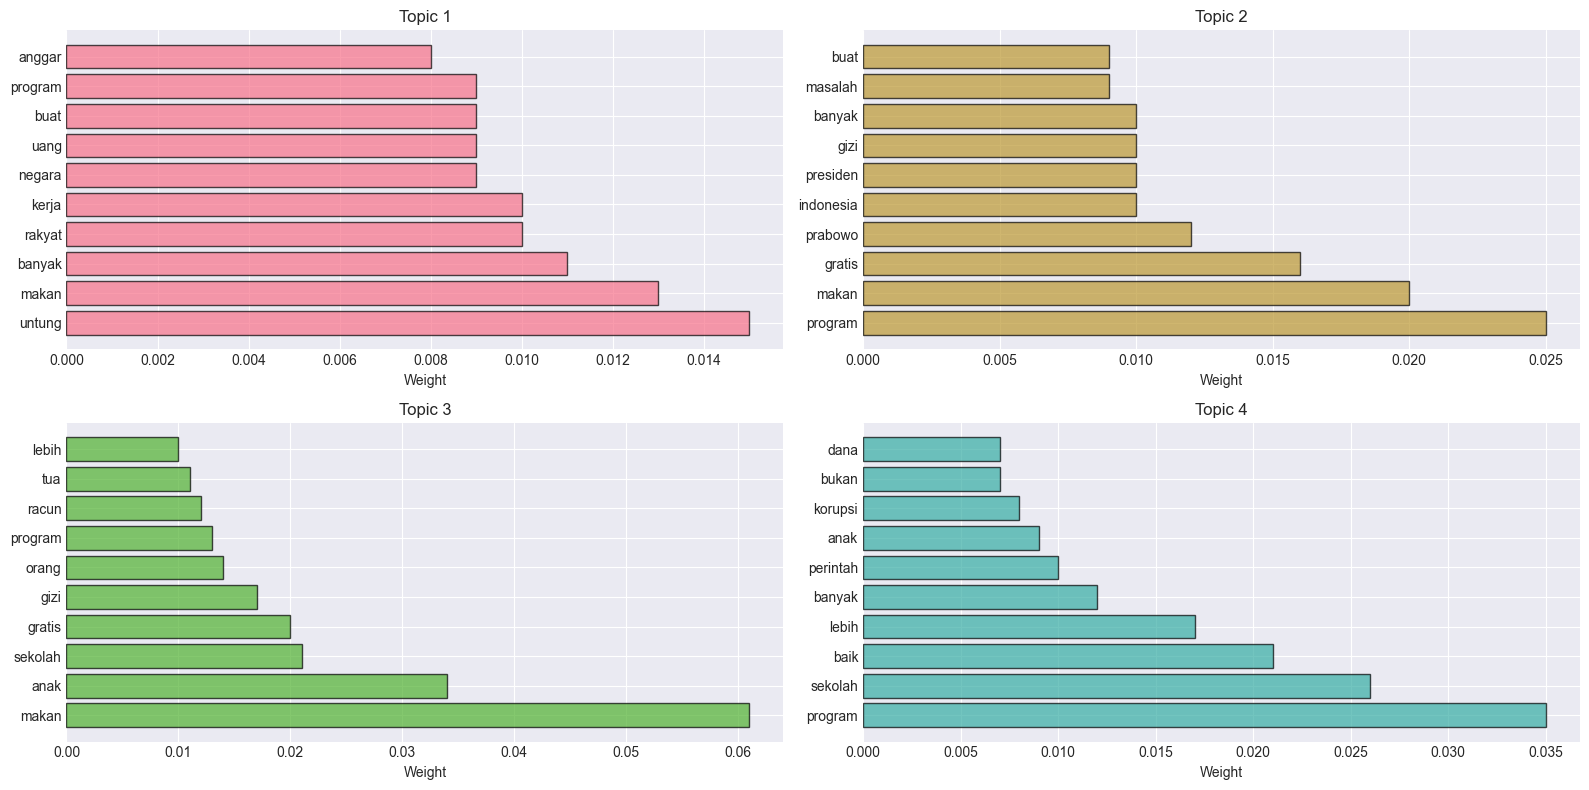


✓ Saved: 04_topics_words.png


In [53]:
# Create topic visualization (bar charts)
num_topics = optimal_topics
rows = (num_topics + 1) // 2

fig, axes = plt.subplots(rows, 2, figsize=(16, 4*rows))
axes = axes.flatten()

for idx, terms in topics_dict.items():
    words = [term[0] for term in terms]
    weights = [term[1] for term in terms]
    
    axes[idx].barh(words[::-1], weights[::-1], color=f'C{idx}', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel('Weight')
    axes[idx].set_title(f'Topic {idx + 1}')
    axes[idx].invert_yaxis()

# Hide extra subplots
for idx in range(num_topics, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('output/visualizations/04_topics_words.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: 04_topics_words.png")

---
## 📊 BAGIAN 9: DOCUMENT-TOPIC DISTRIBUTION

In [54]:
print("\n" + "=" * 70)
print("DOCUMENT-TOPIC DISTRIBUTION ANALYSIS")
print("=" * 70)

# Get document-topic distribution for all documents
doc_topic_dist = []

for doc_id in range(len(corpus)):
    # Get topic distribution for document
    topic_dist = final_lda_model.get_document_topics(corpus[doc_id])
    
    # Create full distribution array
    dist = np.zeros(num_topics)
    for topic_id, prob in topic_dist:
        dist[topic_id] = prob
    
    doc_topic_dist.append(dist)

doc_topic_dist = np.array(doc_topic_dist)

print(f"\nDocument-Topic Distribution Matrix shape: {doc_topic_dist.shape}")
print(f"Documents: {doc_topic_dist.shape[0]}")
print(f"Topics: {doc_topic_dist.shape[1]}")


DOCUMENT-TOPIC DISTRIBUTION ANALYSIS

Document-Topic Distribution Matrix shape: (6805, 4)
Documents: 6805
Topics: 4


In [55]:
# Calculate statistics
topic_prevalence = doc_topic_dist.mean(axis=0)  # Average topic probability
dominant_topics = doc_topic_dist.argmax(axis=1)  # Dominant topic per document
max_probabilities = doc_topic_dist.max(axis=1)  # Max probability per document

print("\n📊 Topic Prevalence Statistics:")
print(f"\n{'Topic':<10} {'Avg Probability':<20} {'Count (Dominant)':<20}")
print("-" * 50)
for topic_id in range(num_topics):
    count_dominant = (dominant_topics == topic_id).sum()
    print(f"{topic_id+1:<10} {topic_prevalence[topic_id]:<20.4f} {count_dominant:<20}")

print(f"\n\n📊 Document Classification Statistics:")
print(f"  Average dominant topic probability: {max_probabilities.mean():.4f}")
print(f"  Min probability: {max_probabilities.min():.4f}")
print(f"  Max probability: {max_probabilities.max():.4f}")
print(f"  Std deviation: {max_probabilities.std():.4f}")


📊 Topic Prevalence Statistics:

Topic      Avg Probability      Count (Dominant)    
--------------------------------------------------
1          0.2200               1458                
2          0.2124               1381                
3          0.3355               2387                
4          0.2320               1579                


📊 Document Classification Statistics:
  Average dominant topic probability: 0.7813
  Min probability: 0.2500
  Max probability: 0.9968
  Std deviation: 0.1631


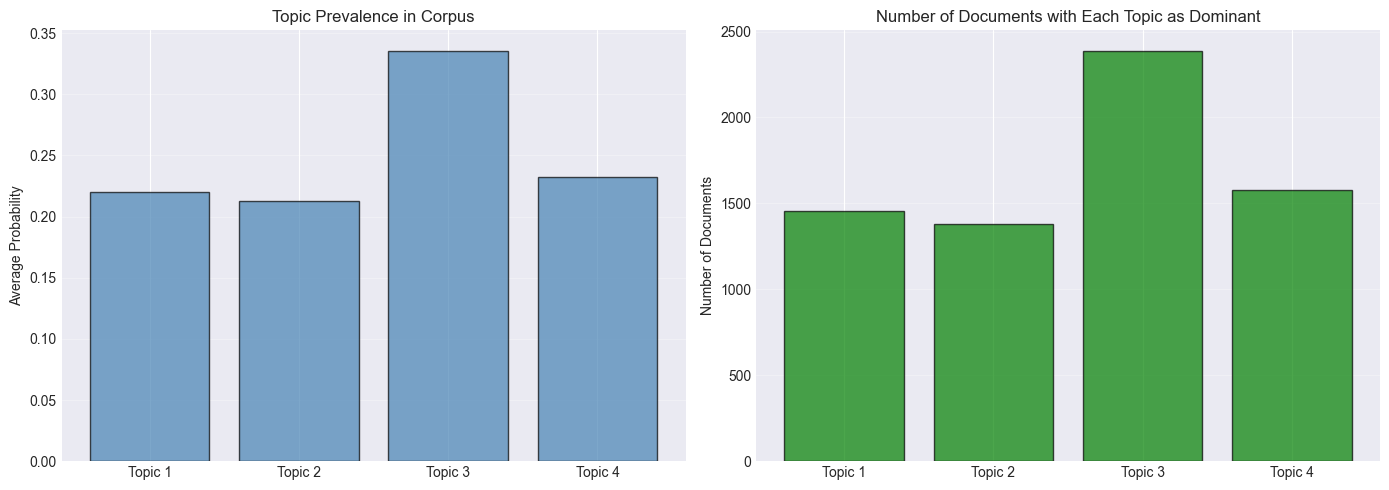

✓ Saved: 05_topic_distribution.png


In [56]:
# Visualize topic distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Topic prevalence
topic_labels = [f'Topic {i+1}' for i in range(num_topics)]
axes[0].bar(topic_labels, topic_prevalence, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Average Probability')
axes[0].set_title('Topic Prevalence in Corpus')
axes[0].grid(True, alpha=0.3, axis='y')

# Dominant topic counts
dominant_counts = [(dominant_topics == i).sum() for i in range(num_topics)]
axes[1].bar(topic_labels, dominant_counts, color='green', edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Number of Documents')
axes[1].set_title('Number of Documents with Each Topic as Dominant')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/visualizations/05_topic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 05_topic_distribution.png")

---
## 📝 BAGIAN 10: SAMPLE DOCUMENT ANALYSIS

In [57]:
print("\n" + "=" * 70)
print("SAMPLE DOCUMENT ANALYSIS")
print("=" * 70)

# Select some interesting documents
interesting_indices = np.argsort(max_probabilities)[-5:][::-1]  # Top 5 confident docs

for idx in interesting_indices:
    original_comment = df_processed.iloc[idx]['Comment']
    dominant_topic = dominant_topics[idx]
    confidence = max_probabilities[idx]
    
    print(f"\n📝 Document {idx + 1}:")
    print(f"  Original: {original_comment[:100]}...")
    print(f"  Dominant Topic: {dominant_topic + 1}")
    print(f"  Confidence: {confidence:.4f}")
    print(f"  Topic Distribution: {doc_topic_dist[idx]}")


SAMPLE DOCUMENT ANALYSIS

📝 Document 6526:
  Original: Usul untuk Pak Prabbowo, jika masuk akal, supaya pemerintah ciptakan setidaknya 20 juta lapangan ker...
  Dominant Topic: 1
  Confidence: 0.9968
  Topic Distribution: [0.99682719 0.00105713 0.00105146 0.0010642 ]

📝 Document 1045:
  Original: inilah yang disebut berita yang benar berita yang turun langsung ke lapangan saya pedagang pasar dan...
  Dominant Topic: 1
  Confidence: 0.9961
  Topic Distribution: [0.99612224 0.00129296 0.00129562 0.0012892 ]

📝 Document 1053:
  Original: saya pedagang pasar dan sejak program mbg berjalan pasar tradisional terasa semakin sepi dan lesu bu...
  Dominant Topic: 1
  Confidence: 0.9960
  Topic Distribution: [0.99600422 0.00132075 0.0013466  0.00132847]

📝 Document 1048:
  Original: saya pedagang pasar dan sejak program mbg berjalan pasar tradisional terasa semakin sepi dan lesu bu...
  Dominant Topic: 1
  Confidence: 0.9960
  Topic Distribution: [0.99596471 0.00134305 0.00134936 0.00134284]

📝

---
## 🎨 BAGIAN 11: WORD CLOUDS PER TOPIC


GENERATING WORD CLOUDS


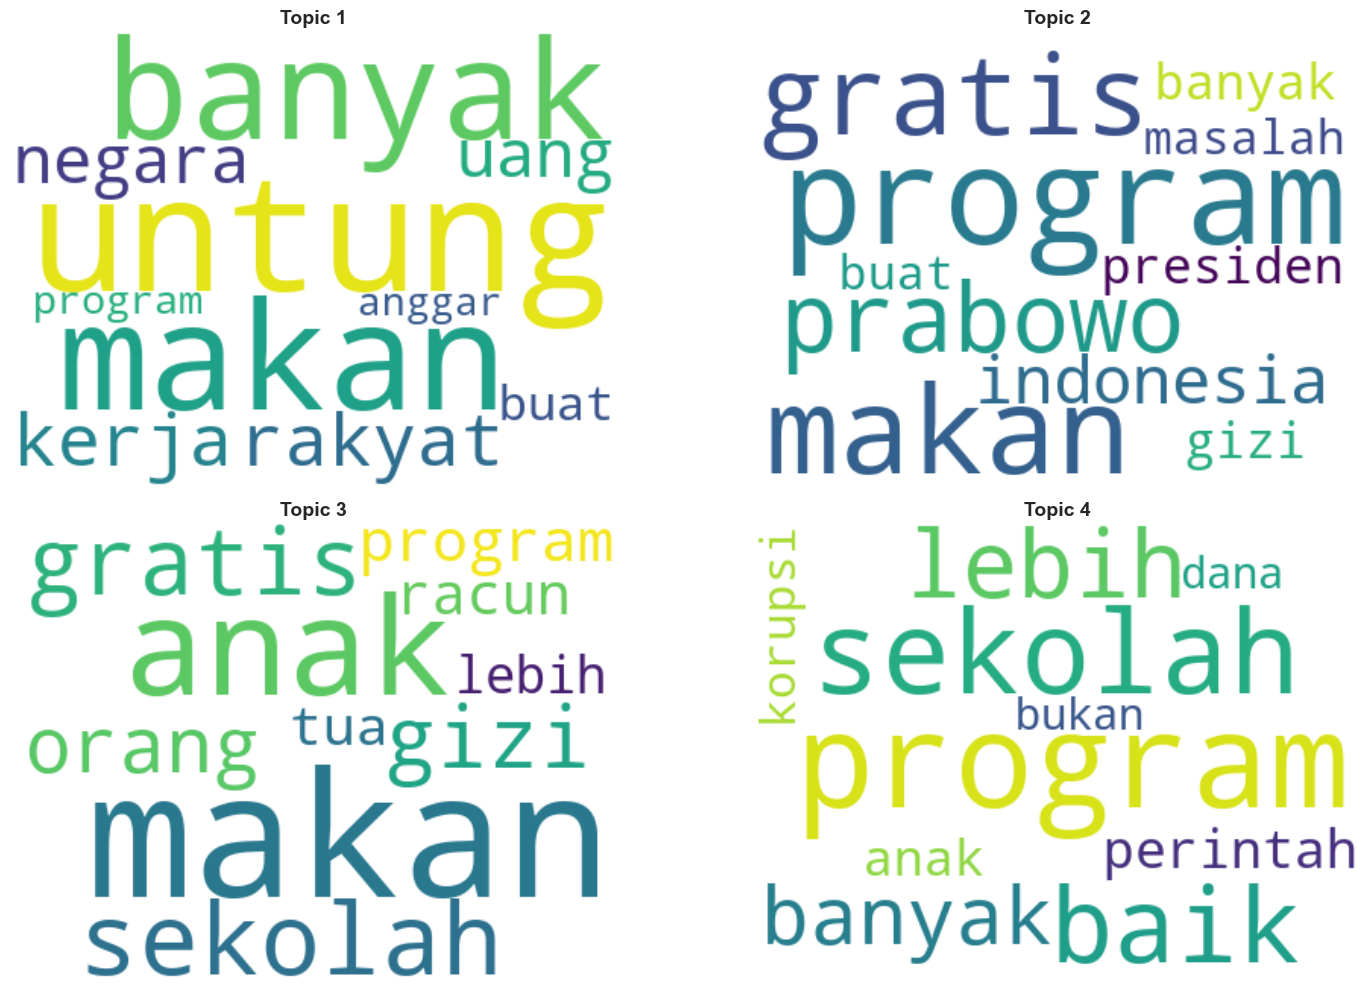


✓ Saved: 06_wordclouds_topics.png


In [58]:
print("\n" + "=" * 70)
print("GENERATING WORD CLOUDS")
print("=" * 70)

# Create word clouds for each topic
fig, axes = plt.subplots(2, 2 if num_topics <= 4 else 3, figsize=(16, 10))
axes = axes.flatten()

for topic_id, terms in topics_dict.items():
    # Create word frequency dict for wordcloud
    word_freq = {term[0]: term[1] for term in terms}
    
    # Generate wordcloud
    wc = WordCloud(
        width=400,
        height=300,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_freq)
    
    # Plot
    axes[topic_id].imshow(wc, interpolation='bilinear')
    axes[topic_id].set_title(f'Topic {topic_id + 1}', fontsize=14, fontweight='bold')
    axes[topic_id].axis('off')

# Hide extra subplots
for idx in range(num_topics, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('output/visualizations/06_wordclouds_topics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: 06_wordclouds_topics.png")

---
## 📊 BAGIAN 12: INTERACTIVE VISUALIZATION (pyLDAvis)

In [59]:
print("\n" + "=" * 70)
print("CREATING INTERACTIVE VISUALIZATION (pyLDAvis)")
print("=" * 70)

# Prepare visualization
print("\n🔄 Preparing pyLDAvis visualization...")

try:
    vis_data = gensimvis.prepare(final_lda_model, corpus, dictionary, sort_topics=False)
    
    # Save HTML
    output_file = 'output/visualizations/07_interactive_ldavis.html'
    pyLDAvis.save_html(vis_data, output_file)
    
    print(f"✓ Interactive visualization created!")
    print(f"  Saved to: {output_file}")
    print(f"\n  Open the HTML file in your browser to explore the topics interactively.")
    print(f"  Features:")
    print(f"    - Click topics to see top words")
    print(f"    - Adjust 'Relevance Metric' slider to see relevant terms")
    print(f"    - Circle size = topic prevalence")
    print(f"    - Distance = topic similarity")
    
except Exception as e:
    print(f"Error creating visualization: {e}")


CREATING INTERACTIVE VISUALIZATION (pyLDAvis)

🔄 Preparing pyLDAvis visualization...
✓ Interactive visualization created!
  Saved to: output/visualizations/07_interactive_ldavis.html

  Open the HTML file in your browser to explore the topics interactively.
  Features:
    - Click topics to see top words
    - Adjust 'Relevance Metric' slider to see relevant terms
    - Circle size = topic prevalence
    - Distance = topic similarity


---
## 📈 BAGIAN 13: ADDITIONAL VISUALIZATIONS


Generating document-topic heatmap (sample)...


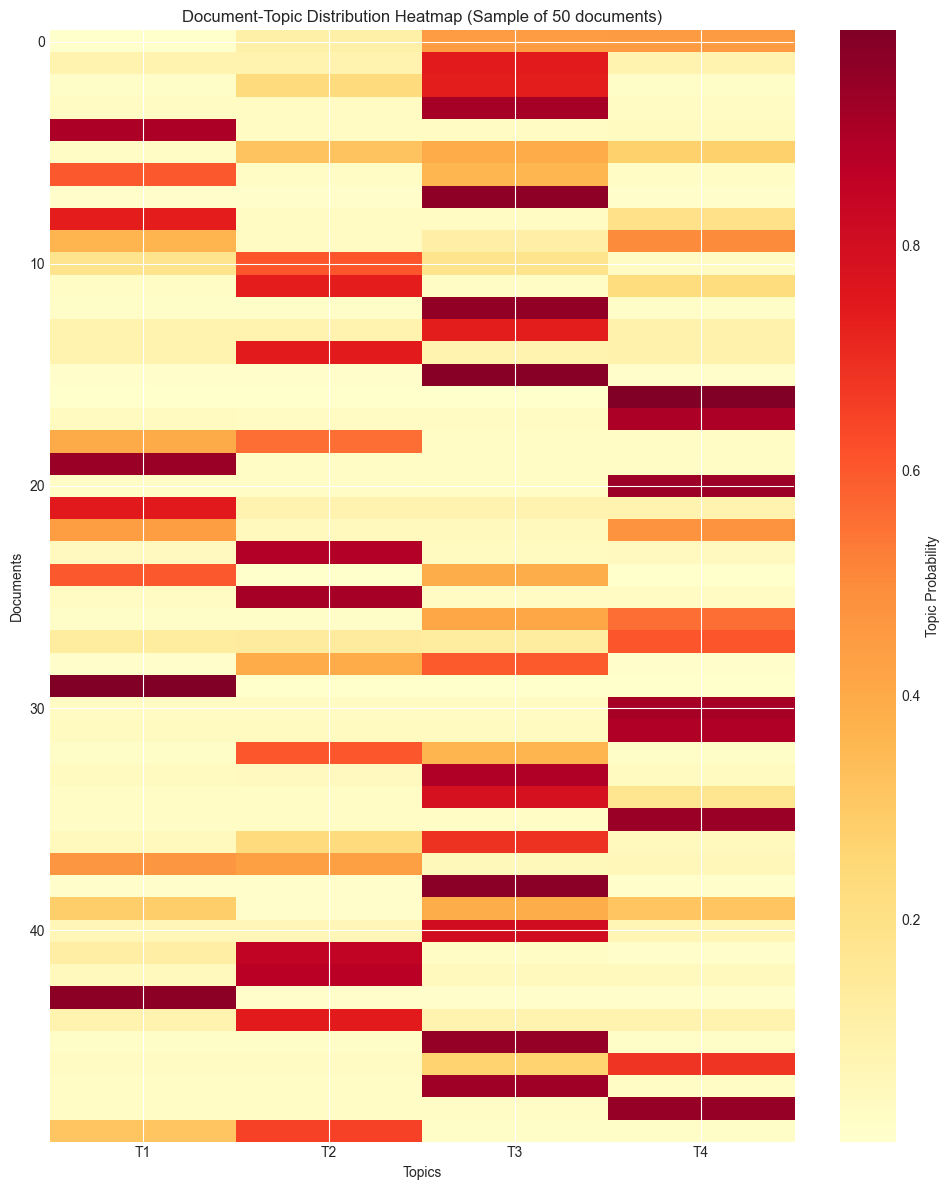

✓ Saved: 08_document_topic_heatmap.png


In [60]:
# Heatmap of document-topic distribution (sample)
print("\nGenerating document-topic heatmap (sample)...")

# Select 50 random documents
sample_indices = np.random.choice(len(doc_topic_dist), min(50, len(doc_topic_dist)), replace=False)
sample_dist = doc_topic_dist[sample_indices]

fig, ax = plt.subplots(figsize=(10, 12))

# Create heatmap
im = ax.imshow(sample_dist, cmap='YlOrRd', aspect='auto')
ax.set_xlabel('Topics')
ax.set_ylabel('Documents')
ax.set_title('Document-Topic Distribution Heatmap (Sample of 50 documents)')
ax.set_xticks(range(num_topics))
ax.set_xticklabels([f'T{i+1}' for i in range(num_topics)])

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Topic Probability')

plt.tight_layout()
plt.savefig('output/visualizations/08_document_topic_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 08_document_topic_heatmap.png")


Generating confidence distribution plot...


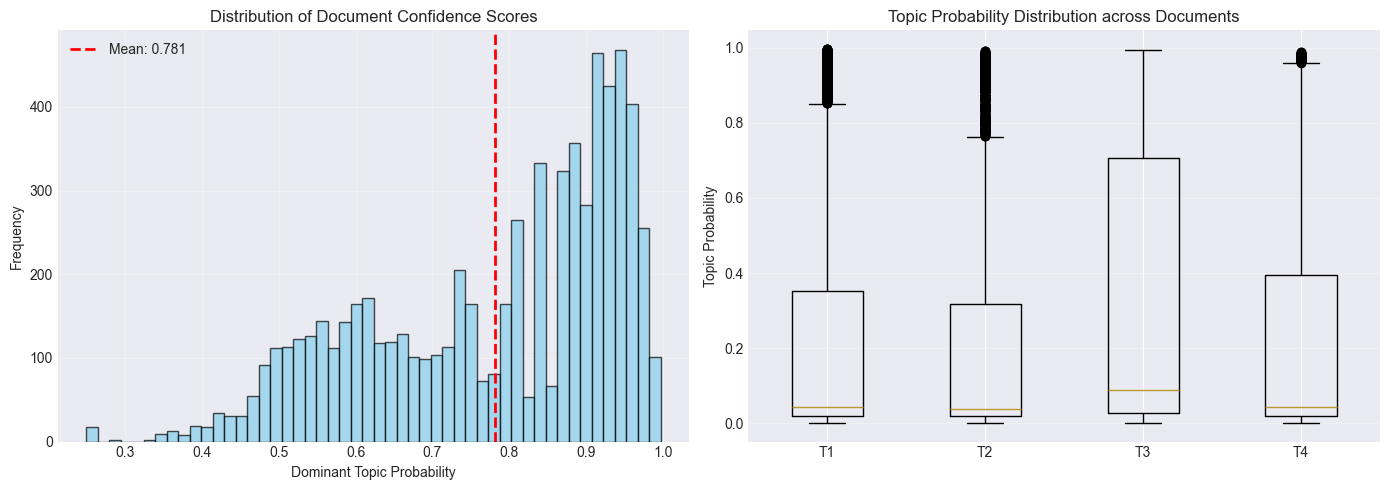

✓ Saved: 09_confidence_distribution.png


In [61]:
# Distribution of dominant topic probabilities
print("\nGenerating confidence distribution plot...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of max probabilities
axes[0].hist(max_probabilities, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(max_probabilities.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {max_probabilities.mean():.3f}')
axes[0].set_xlabel('Dominant Topic Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Document Confidence Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot of topic probabilities
axes[1].boxplot([doc_topic_dist[:, i] for i in range(num_topics)],
                labels=[f'T{i+1}' for i in range(num_topics)])
axes[1].set_ylabel('Topic Probability')
axes[1].set_title('Topic Probability Distribution across Documents')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('output/visualizations/09_confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: 09_confidence_distribution.png")

---
## 📋 BAGIAN 14: COMPREHENSIVE SUMMARY REPORT

In [62]:
# Create comprehensive summary
print("\n" + "="*70)
print("COMPREHENSIVE TOPIC MODELLING SUMMARY REPORT")
print("="*70)

summary_report = f"""
{'='*70}
TOPIC MODELLING PROJECT - SUMMARY REPORT
{'='*70}

DATASET INFORMATION
{'-'*70}
Dataset: BBC News Indonesia - "Setahun Program MBG - Siapa yang diuntungkan?"
Total Comments: {len(df_processed):,}
Source Column: Comment
Processing Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

PREPROCESSING SUMMARY
{'-'*70}
Original Documents: {preprocessor.stats['original']}
After Cleaning: {preprocessor.stats['after_cleaning']}
After Stopword Removal: {preprocessor.stats['after_removal']}
Final Documents: {preprocessor.stats['final']}

TF-IDF VECTORIZATION
{'-'*70}
Max Features: 5,000
Min Document Frequency: 2
Max Document Frequency: 0.8 (80%)
N-gram Range: (1, 2) - Unigram and Bigram
Total Features Extracted: {tfidf_matrix.shape[1]:,}
Matrix Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%

LDA MODEL CONFIGURATION
{'-'*70}
Library: Gensim (LdaMulticore)
Optimal Number of Topics: {optimal_topics}
Coherence Score (C_v): {coherence_scores[optimal_topics]:.4f}
Perplexity: {perplexity_scores[optimal_topics]:.4f}
Number of Passes: 10
Number of Workers: 4

TOPIC ANALYSIS
{'-'*70}
"""

for topic_id, terms in topics_dict.items():
    summary_report += f"\nTopic {topic_id + 1}:\n"
    summary_report += f"  Top 10 Words:\n"
    for rank, (word, weight) in enumerate(terms, 1):
        summary_report += f"    {rank:2d}. {word:20s} (weight: {weight:.4f})\n"

summary_report += f"""
{'-'*70}
DOCUMENT CLASSIFICATION
{'-'*70}
Average Dominant Topic Confidence: {max_probabilities.mean():.4f}
Min Confidence: {max_probabilities.min():.4f}
Max Confidence: {max_probabilities.max():.4f}
Standard Deviation: {max_probabilities.std():.4f}

Topic Distribution:
"""

for topic_id in range(num_topics):
    count_dominant = (dominant_topics == topic_id).sum()
    percentage = (count_dominant / len(dominant_topics)) * 100
    summary_report += f"  Topic {topic_id + 1}: {count_dominant:4d} documents ({percentage:5.2f}%)\n"

summary_report += f"""
{'-'*70}
OUTPUT FILES
{'-'*70}
Data Files:
  - output/data/preprocessed_comments.csv

Models:
  - output/models/lda_model_final.model

Visualizations:
  - 01_comment_statistics.png - Comment length and word count distributions
  - 02_top_idf_features.png - Top 20 features by IDF score
  - 03_coherence_perplexity.png - Model evaluation metrics
  - 04_topics_words.png - Top words per topic
  - 05_topic_distribution.png - Topic prevalence and dominant counts
  - 06_wordclouds_topics.png - Word clouds for each topic
  - 07_interactive_ldavis.html - Interactive visualization (open in browser)
  - 08_document_topic_heatmap.png - Document-topic distribution heatmap
  - 09_confidence_distribution.png - Document confidence scores

{'='*70}
END OF REPORT
{'='*70}
"""

print(summary_report)

# Save report
with open('output/reports/topic_modelling_summary.txt', 'w') as f:
    f.write(summary_report)

print("\n✓ Saved: output/reports/topic_modelling_summary.txt")


COMPREHENSIVE TOPIC MODELLING SUMMARY REPORT

TOPIC MODELLING PROJECT - SUMMARY REPORT

DATASET INFORMATION
----------------------------------------------------------------------
Dataset: BBC News Indonesia - "Setahun Program MBG - Siapa yang diuntungkan?"
Total Comments: 6,805
Source Column: Comment
Processing Date: 2026-06-04 03:43:37

PREPROCESSING SUMMARY
----------------------------------------------------------------------
Original Documents: 6811
After Cleaning: 6807
After Stopword Removal: 6805
Final Documents: 6805

TF-IDF VECTORIZATION
----------------------------------------------------------------------
Max Features: 5,000
Min Document Frequency: 2
Max Document Frequency: 0.8 (80%)
N-gram Range: (1, 2) - Unigram and Bigram
Total Features Extracted: 5,000
Matrix Sparsity: 99.67%

LDA MODEL CONFIGURATION
----------------------------------------------------------------------
Library: Gensim (LdaMulticore)
Optimal Number of Topics: 4
Coherence Score (C_v): 0.5247
Perplexity: -

---
## 💾 BAGIAN 15: SAVE ALL ARTIFACTS

In [63]:
print("\n" + "="*70)
print("SAVING ALL PROJECT ARTIFACTS")
print("="*70)

# Save dictionary
pickle.dump(dictionary, open('output/models/dictionary.pkl', 'wb'))
print("✓ Saved: dictionary.pkl")

# Save corpus
pickle.dump(corpus, open('output/models/corpus.pkl', 'wb'))
print("✓ Saved: corpus.pkl")

# Save doc-topic distribution
np.save('output/models/doc_topic_distribution.npy', doc_topic_dist)
print("✓ Saved: doc_topic_distribution.npy")

# Save topic information
topic_info = {
    'num_topics': num_topics,
    'optimal_topics': optimal_topics,
    'coherence_scores': coherence_scores,
    'perplexity_scores': perplexity_scores,
    'topics_dict': topics_dict
}

pickle.dump(topic_info, open('output/models/topic_info.pkl', 'wb'))
print("✓ Saved: topic_info.pkl")

# Save processed comments with topic assignments
df_with_topics = df_processed.copy()
df_with_topics['dominant_topic'] = dominant_topics
df_with_topics['dominant_topic_probability'] = max_probabilities
df_with_topics.to_csv('output/data/comments_with_topics.csv', index=False)
print("✓ Saved: comments_with_topics.csv")

print("\n" + "="*70)
print("✅ ALL ARTIFACTS SAVED SUCCESSFULLY!")
print("="*70)


SAVING ALL PROJECT ARTIFACTS
✓ Saved: dictionary.pkl
✓ Saved: corpus.pkl
✓ Saved: doc_topic_distribution.npy
✓ Saved: topic_info.pkl
✓ Saved: comments_with_topics.csv

✅ ALL ARTIFACTS SAVED SUCCESSFULLY!


---
## 🎓 BAGIAN 16: FINAL SUMMARY & NEXT STEPS

In [64]:
print("\n" + "="*70)
print("PROJECT COMPLETION SUMMARY")
print("="*70)

print(f"""
✅ TOPIC MODELLING PROJECT COMPLETED SUCCESSFULLY!

📊 KEY METRICS:
  • Total Comments Analyzed: {len(df_processed):,}
  • Optimal Topics Found: {optimal_topics}
  • Coherence Score: {coherence_scores[optimal_topics]:.4f}
  • Average Document Confidence: {max_probabilities.mean():.4f}

📁 OUTPUT STRUCTURE:
  output/
  ├── data/
  │   ├── preprocessed_comments.csv
  │   └── comments_with_topics.csv
  ├── models/
  │   ├── lda_model_final.model
  │   ├── dictionary.pkl
  │   ├── corpus.pkl
  │   ├── doc_topic_distribution.npy
  │   └── topic_info.pkl
  ├── visualizations/
  │   ├── 01_comment_statistics.png
  │   ├── 02_top_idf_features.png
  │   ├── 03_coherence_perplexity.png
  │   ├── 04_topics_words.png
  │   ├── 05_topic_distribution.png
  │   ├── 06_wordclouds_topics.png
  │   ├── 07_interactive_ldavis.html  ← OPEN IN BROWSER!
  │   ├── 08_document_topic_heatmap.png
  │   └── 09_confidence_distribution.png
  └── reports/
      └── topic_modelling_summary.txt

🔍 HOW TO EXPLORE RESULTS:

1. Interactive Visualization:
   → Open 'output/visualizations/07_interactive_ldavis.html' in your web browser
   → Click on topics to see top terms
   → Use relevance metric slider to adjust term relevance

2. Static Visualizations:
   → Review all PNG files for topic distributions and statistics

3. Detailed Analysis:
   → Load 'output/data/comments_with_topics.csv' to see topic assignments
   → Read 'output/reports/topic_modelling_summary.txt' for comprehensive summary

📝 NEXT STEPS FOR YOUR THESIS:

1. Topic Labeling:
   → Assign meaningful labels to each topic based on top terms
   → Document your interpretation rationale

2. Domain Validation:
   → Review topic coherence with domain experts
   → Check if topics align with program expectations

3. Statistical Analysis:
   → Perform sentiment analysis on each topic
   → Calculate topic-specific statistics

4. Report Writing:
   → Use this analysis for your methodology section
   → Include selected visualizations in thesis
   → Document all parameters and decisions

5. Validation (Optional):
   → Perform cross-validation with train-test split
   → Test model stability with different random states
   → Conduct sensitivity analysis

💡 KEY FINDINGS TO EXPLORE:
   • What are the main discussion topics about MBG?
   • How do topics relate to program benefits/criticisms?
   • Are there specific user groups discussing different topics?
   • What is the sentiment distribution across topics?

""")

print("="*70)
print("Thank you for using this Topic Modelling Pipeline!")
print("="*70)


PROJECT COMPLETION SUMMARY

✅ TOPIC MODELLING PROJECT COMPLETED SUCCESSFULLY!

📊 KEY METRICS:
  • Total Comments Analyzed: 6,805
  • Optimal Topics Found: 4
  • Coherence Score: 0.5247
  • Average Document Confidence: 0.7813

📁 OUTPUT STRUCTURE:
  output/
  ├── data/
  │   ├── preprocessed_comments.csv
  │   └── comments_with_topics.csv
  ├── models/
  │   ├── lda_model_final.model
  │   ├── dictionary.pkl
  │   ├── corpus.pkl
  │   ├── doc_topic_distribution.npy
  │   └── topic_info.pkl
  ├── visualizations/
  │   ├── 01_comment_statistics.png
  │   ├── 02_top_idf_features.png
  │   ├── 03_coherence_perplexity.png
  │   ├── 04_topics_words.png
  │   ├── 05_topic_distribution.png
  │   ├── 06_wordclouds_topics.png
  │   ├── 07_interactive_ldavis.html  ← OPEN IN BROWSER!
  │   ├── 08_document_topic_heatmap.png
  │   └── 09_confidence_distribution.png
  └── reports/
      └── topic_modelling_summary.txt

🔍 HOW TO EXPLORE RESULTS:

1. Interactive Visualization:
   → Open 'output/visualiz

In [65]:
# Display file structure
import os
import subprocess

print("\n📁 Final Output Directory Structure:\n")
os.system('find output -type f -exec ls -lh {} \; | awk \'{print $9, "(" $5 ")"}\'')


📁 Final Output Directory Structure:



255